# Param Shah
## 240905320
## CSE-D 33
### Lab 5: Logistic Regression and Stochastic Gradient Descent (SGD)

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets 
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, accuracy_score, log_loss

Sample Questions:\
Logistic Regression using Scikit-Learn

Confusion Matrix:
[[19  0]
 [ 0 26]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        26

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



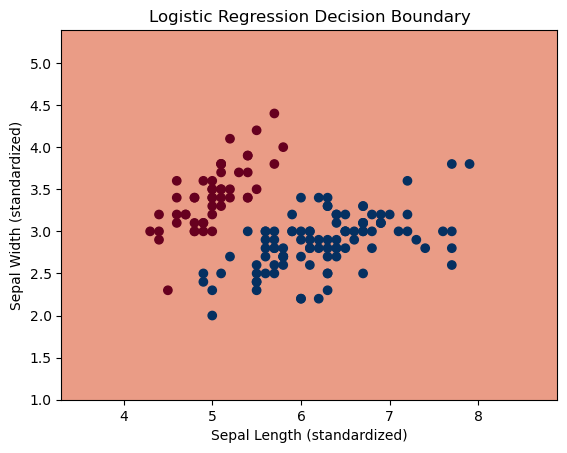

In [38]:
iris = datasets.load_iris()
X =iris.data[:,:2]
y = (iris.target != 0) * 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) 
 
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test) 
 
model = LogisticRegression(solver='liblinear') 
 
model.fit(X_train, y_train) 
 
y_pred = model.predict(X_test) 
 
print("Confusion Matrix:") 
print(confusion_matrix(y_test, y_pred)) 
 
print("\nClassification Report:") 
print(classification_report(y_test, y_pred)) 
 
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1 
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1 
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01)) 
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) 
Z = Z.reshape(xx.shape) 
 
plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8) 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu) 
plt.xlabel('Sepal Length (standardized)') 
plt.ylabel('Sepal Width (standardized)') 
plt.title('Logistic Regression Decision Boundary') 
plt.show()


Q1) Let’s say we have a fictional dataset of pairs of variables, a mother and her daughter’s heights. \
Create  a  CSV  file  for  the  above  training  data  and  write  a  Python  function  program  to  find  the  fitted  linear regression with gradient descent technique. \
Compare the coefficients obtained from the sklearn model with your program. Compute  the log loss, MSE  and RMSE. \
Plot the graph Daughter height  (Y-axis) vs Mother height (X-axis) with blue colour. Also, plot the line of best fit with red colour. \
Predict her daughter’s height with given a new mother height as 63. Plot the graph of error in y-axis and iteration in x-axis with 4 epochs 
(6x4=24 iterations).

SKLEARN
Coefficient: 1.2060301507537687
Intercept: -13.249581239530976
MSE: 6.101619207146855
RMSE: 2.470145584200829
Prediction for 63: 62.73031825795645

SGD
Learning Rate: 0.0001
Epochs: 4
Iterations: 24
Coefficient: 1.028444420968888
Intercept: 0.017026664309387613
MSE: 10.584360649385763
RMSE: 3.2533614384795557
Prediction for 63: 64.80902518534934

COMPARISON
  Parameter    Sklearn       SGD
Coefficient   1.206030  1.028444
  Intercept -13.249581  0.017027
        MSE   6.101619 10.584361
       RMSE   2.470146  3.253361


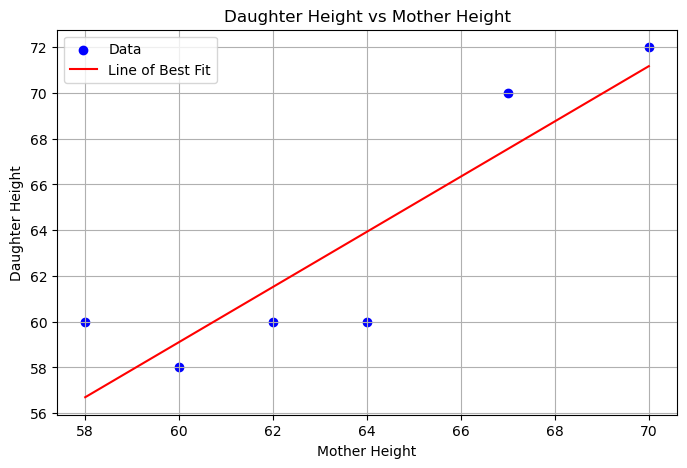

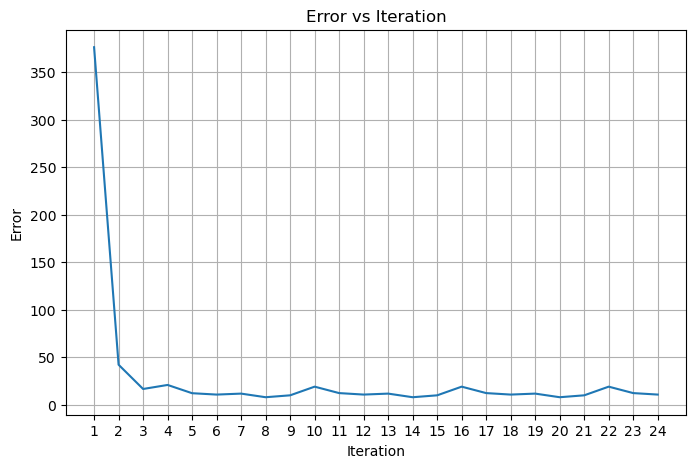

In [39]:
data = pd.read_csv("mother_daughter_height.csv")

X = data["mother_height"].values
y = data["daughter_height"].values

X_sklearn = X.reshape(-1, 1)

model = LinearRegression()
model.fit(X_sklearn, y)

sklearn_w = model.coef_[0]
sklearn_b = model.intercept_

sklearn_pred = model.predict(X_sklearn)
sklearn_mse = mean_squared_error(y, sklearn_pred)
sklearn_rmse = np.sqrt(sklearn_mse)

print("SKLEARN")
print("Coefficient:", sklearn_w)
print("Intercept:", sklearn_b)
print("MSE:", sklearn_mse)
print("RMSE:", sklearn_rmse)
print("Prediction for 63:", model.predict([[63]])[0])

learning_rate = 0.0001
epochs = 4

w = 0.0
b = 0.0

errors = []
iterations = []

iteration = 0

for epoch in range(epochs):
    for i in range(len(X)):
        xi = X[i]
        yi = y[i]

        y_pred = w * xi + b
        error = y_pred - yi

        dw = 2 * error * xi
        db = 2 * error

        w -= learning_rate * dw
        b -= learning_rate * db

        iteration += 1

        pred = w * X + b
        mse = np.mean((y - pred) ** 2)

        iterations.append(iteration)
        errors.append(mse)

sgd_pred = w * X + b
sgd_mse = np.mean((y - sgd_pred) ** 2)
sgd_rmse = np.sqrt(sgd_mse)

print("\nSGD")
print("Learning Rate:", learning_rate)
print("Epochs:", epochs)
print("Iterations:", iteration)
print("Coefficient:", w)
print("Intercept:", b)
print("MSE:", sgd_mse)
print("RMSE:", sgd_rmse)
print("Prediction for 63:", w * 63 + b)

comparison = pd.DataFrame({
    "Parameter": ["Coefficient", "Intercept", "MSE", "RMSE"],
    "Sklearn": [sklearn_w, sklearn_b, sklearn_mse, sklearn_rmse],
    "SGD": [w, b, sgd_mse, sgd_rmse]
})

print("\nCOMPARISON")
print(comparison.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="blue", label="Data")

x_line = np.linspace(X.min(), X.max(), 100)
y_line = sklearn_w * x_line + sklearn_b

plt.plot(x_line, y_line, color="red", label="Line of Best Fit")
plt.xlabel("Mother Height")
plt.ylabel("Daughter Height")
plt.title("Daughter Height vs Mother Height")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(iterations, errors)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error vs Iteration")
plt.xticks(range(1, 25))
plt.grid(True)
plt.show()

Q2) Create a CSV file for the above training data of number of hours of study vs outcome of examination and write a Python function program to find the fitted logistic regression with gradient descent technique.  \
Compare the coefficients obtained from the sklearn model with 
your program. Compute the predicted y and assign the class label (prediction = 0 IF p(fail) < 0.5 and prediction = 1 IF p(pass) >= 0.5) and compute the accuracy. \
Find the error for each iteration and predict the probability 
that a student will pass the exam if they study for
a) 3.5 hours 
b) 7.5 hours \
Plot the graph of error in y-axis 
and iteration in x-axis with 3 epochs (8x3=24 iterations)

SKLEARN
Coefficient: 1.1697993675705602
Intercept: -5.264107913297967
Log Loss: 0.1678061314011558
Accuracy: 1.0

Predictions:
Hours: 1 Probability: 0.016394023388154193 Class: 0
Hours: 2 Probability: 0.0509552005619737 Class: 0
Hours: 3 Probability: 0.14745413744358804 Class: 0
Hours: 4 Probability: 0.35780348519787764 Class: 0
Hours: 5 Probability: 0.6421915702717962 Class: 1
Hours: 6 Probability: 0.8525431574197273 Class: 1
Hours: 7 Probability: 0.9490437588217111 Class: 1
Hours: 8 Probability: 0.9836056296174714 Class: 1

Probability of passing at 3.5 hours: 0.23688930646117637
Probability of passing at 7.5 hours: 0.9709536906284063

SGD
Learning Rate: 0.01
Epochs: 3
Iterations: 24
Coefficient: 0.15473772325304522
Intercept: -0.013858187869013647
Log Loss: 0.6094625864836312
Accuracy: 0.5

Predictions:
Hours: 1 Probability: 0.5351617483445312 Class: 1
Hours: 2 Probability: 0.5733707713028939 Class: 1
Hours: 3 Probability: 0.6107236307586401 Class: 1
Hours: 4 Probability: 0.64682057

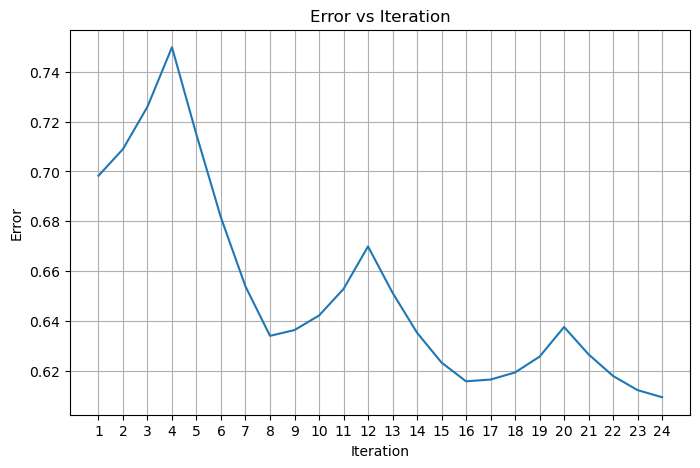

In [41]:
data = pd.read_csv("student_pass.csv")

X = data["hours_of_study"].values
y = data["pass"].values

X_sklearn = X.reshape(-1, 1)

model = LogisticRegression()
model.fit(X_sklearn, y)

sklearn_w = model.coef_[0][0]
sklearn_b = model.intercept_[0]

sklearn_prob = model.predict_proba(X_sklearn)[:, 1]
sklearn_pred = (sklearn_prob >= 0.5).astype(int)

sklearn_accuracy = accuracy_score(y, sklearn_pred)
sklearn_logloss = log_loss(y, sklearn_prob)

print("SKLEARN")
print("Coefficient:", sklearn_w)
print("Intercept:", sklearn_b)
print("Log Loss:", sklearn_logloss)
print("Accuracy:", sklearn_accuracy)

print("\nPredictions:")
for hours, prob, pred in zip(X, sklearn_prob, sklearn_pred):
    print(
        "Hours:", hours,
        "Probability:", prob,
        "Class:", pred
    )

prob_3_5 = model.predict_proba([[3.5]])[0][1]
prob_7_5 = model.predict_proba([[7.5]])[0][1]

print("\nProbability of passing at 3.5 hours:", prob_3_5)
print("Probability of passing at 7.5 hours:", prob_7_5)

learning_rate = 0.01
epochs = 3

w = 0.0
b = 0.0

errors = []
iterations = []

iteration = 0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    for i in range(len(X)):
        xi = X[i]
        yi = y[i]

        z = w * xi + b
        p = sigmoid(z)

        error = p - yi

        dw = error * xi
        db = error

        w -= learning_rate * dw
        b -= learning_rate * db

        iteration += 1

        probabilities = sigmoid(w * X + b)

        current_logloss = -np.mean(
            y * np.log(probabilities + 1e-15) +
            (1 - y) * np.log(1 - probabilities + 1e-15)
        )

        iterations.append(iteration)
        errors.append(current_logloss)

sgd_prob = sigmoid(w * X + b)
sgd_pred = (sgd_prob >= 0.5).astype(int)

sgd_accuracy = accuracy_score(y, sgd_pred)
sgd_logloss = log_loss(y, sgd_prob)

print("\nSGD")
print("Learning Rate:", learning_rate)
print("Epochs:", epochs)
print("Iterations:", iteration)
print("Coefficient:", w)
print("Intercept:", b)
print("Log Loss:", sgd_logloss)
print("Accuracy:", sgd_accuracy)

print("\nPredictions:")
for hours, prob, pred in zip(X, sgd_prob, sgd_pred):
    print(
        "Hours:", hours,
        "Probability:", prob,
        "Class:", pred
    )

sgd_prob_3_5 = sigmoid(w * 3.5 + b)
sgd_prob_7_5 = sigmoid(w * 7.5 + b)

print("\nSGD Probability of passing at 3.5 hours:", sgd_prob_3_5)
print("SGD Probability of passing at 7.5 hours:", sgd_prob_7_5)

comparison = pd.DataFrame({
    "Parameter": [
        "Coefficient",
        "Intercept",
        "Log Loss",
        "Accuracy"
    ],
    "Sklearn": [
        sklearn_w,
        sklearn_b,
        sklearn_logloss,
        sklearn_accuracy
    ],
    "SGD": [
        w,
        b,
        sgd_logloss,
        sgd_accuracy
    ]
})

print("\nCOMPARISON")
print(comparison.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(iterations, errors)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error vs Iteration")
plt.xticks(range(1, 25))
plt.grid(True)
plt.show()

Q3) Consider  the  above  dataset  with  two  independent  variables  (X1  and  X2)  and  a  dependent  variable  (Y). 
Implement  in  python,  how  you  can  perform  the  logistic  regression  to  model  the  relationship  between  the 
independent variables and the dependent variable.

In [43]:
data = pd.read_csv("logistic_data.csv")

X = data[["X1", "X2"]].values
y = data["Y"].values

model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=10000
)

model.fit(X, y)

print("Classes:")
print(model.classes_)

print("\nCoefficients:")
print(model.coef_)

print("\nIntercepts:")
print(model.intercept_)

y_pred = model.predict(X)

print("\nActual Y:")
print(y)

print("\nPredicted Y:")
print(y_pred)

accuracy = accuracy_score(y, y_pred)

print("\nAccuracy:", accuracy)

probabilities = model.predict_proba(X)

print("\nPredicted Probabilities:")
print(probabilities)

print("\nPredictions for each observation:")

for i in range(len(X)):
    print(
        "X1:", X[i][0],
        "X2:", X[i][1],
        "Actual:", y[i],
        "Predicted:", y_pred[i]
    )

Classes:
[-14  -8  -7  -1   1   2]

Coefficients:
[[-0.28105875  0.81586047]
 [ 0.6901396   0.45317853]
 [-0.5936846   0.16543592]
 [ 0.1575671  -0.17984209]
 [-0.57328993 -0.74286533]
 [ 0.60032658 -0.51176751]]

Intercepts:
[-2.60961643 -3.81386796  1.6615656   1.05419507  3.45577837  0.25194535]

Actual Y:
[  2 -14   1  -1  -7  -8]

Predicted Y:
[  2 -14   1  -1  -7  -8]

Accuracy: 1.0

Predicted Probabilities:
[[3.43842251e-03 3.49134702e-02 3.67915007e-02 2.86467515e-01
  9.68106540e-02 5.41578438e-01]
 [7.34437665e-01 8.44191901e-02 1.54723406e-01 2.39160037e-02
  6.77213392e-04 1.82652215e-03]
 [2.09013968e-03 1.65562356e-03 1.09484946e-01 1.26427402e-01
  6.72091509e-01 8.82503801e-02]
 [1.77336495e-02 4.74389476e-02 1.35357483e-01 3.52041080e-01
  1.40711765e-01 3.06717074e-01]
 [1.42137187e-01 2.63907017e-02 5.52056648e-01 1.60199482e-01
  8.95729255e-02 2.96430551e-02]
 [1.00170005e-01 8.05154155e-01 1.15805139e-02 5.10352967e-02
  1.36394463e-04 3.19236355e-02]]

Prediction